# LAT Workshop Tutorial #2: EMRIs and LISA Response + TDI

In [15]:
# # if running in google colab
# !apt-get install liblapacke-dev libgsl-dev
# !ln -s /usr/lib/x86_64-linux-gnu/libhdf5_serial_hl.so /usr/lib/x86_64-linux-gnu/libhdf5_hl.so
# !ln -s /usr/lib/x86_64-linux-gnu/libhdf5_serial.so /usr/lib/x86_64-linux-gnu/libhdf5.so
# !pip install eryn lisaanalysistools
# !pip install fastlisaresponse fastemriwaveforms

In [16]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from lisatools.utils.constants import *
from copy import deepcopy  # can be useful

In the second tutorial, we will

* generate EMRI waveforms,（Extreme Mass Ratio Inspiral（极端质量比例旋入））
* use tools from our last lesson to estimate EMRI SNRs,
* examine changing EMRI trajectories,
* add in the LISA response function,
* and calculate Likelihoods for EMRIs + Response + Trajectory. 

## Task 1: Generate an EMRI Waveform for a typical EMRI

Generate a relativistic Schwarzschild eccentric EMRI Waveform in the detector frame (use `GenerateEMRIWaveform` class rather than `FastSchwarzschildEccentricFlux`. Choose a set of reasonable parameters.

Useful documentation:
* [GenerateEMRIWaveform](https://bhptoolkit.org/FastEMRIWaveforms/html/user/main.html#few.waveform.GenerateEMRIWaveform)
* [FastSchwarzschildEccentricFlux](https://bhptoolkit.org/FastEMRIWaveforms/html/user/main.html#few.waveform.FastSchwarzschildEccentricFlux)

In [17]:
# import few
# import os
# # 打印出数据存放的绝对路径
# print(os.path.join(few.__path__[0], "utils", "data"))

wsl没有VPN，需要从windows下载下来之后，装到wsl上

In [18]:
# import os
# import shutil

# print("正在扫描 FEW 2.0 真实的下载老巢...")
# home_dir = os.path.expanduser("~")
# real_target_dir = None

# # 去 Linux 常用的数据存放点抓它现行
# for target in [".local/share", ".cache", ".config"]:
#     search_path = os.path.join(home_dir, target)
#     if os.path.exists(search_path):
#         for root, dirs, files in os.walk(search_path):
#             # 只要文件名里包含它，不管是不是没下完的临时文件，都抓出来
#             if any("SchwarzschildEccentricInput" in f for f in files):
#                 real_target_dir = root
#                 break
#     if real_target_dir:
#         break

# if real_target_dir:
#     print(f"\n🎯 破案了！它真正想要数据的目录是:\n{real_target_dir}")
    
#     # 你之前放错的“旧版路径”文件
#     old_wrong_path = "/home/yudh/miniconda3/envs/lisa_env/lib/python3.12/site-packages/few/utils/data/SchwarzschildEccentricInput.hdf5"
#     new_correct_path = os.path.join(real_target_dir, "SchwarzschildEccentricInput.hdf5")
    
#     if os.path.exists(old_wrong_path):
#         shutil.copy(old_wrong_path, new_correct_path)
#         print("✅ 已经成功把 12MB 的完整文件覆盖到 2.0 版本的专属老巢！")
#         print("🚀 现在立刻 Restart Kernel，再跑一次波形生成，绝对秒出图！")
#     else:
#         print("旧文件不见了？请去上面的路径手动粘贴一下。")
# else:
#     print("没有找到刚才下载 1% 的痕迹，请尝试用平台命令强制打印：")
#     import platformdirs
#     print(platformdirs.user_data_dir("few"))
#     print(platformdirs.user_data_dir("FastEMRIWaveforms"))

In [19]:
from few.waveform import GenerateEMRIWaveform

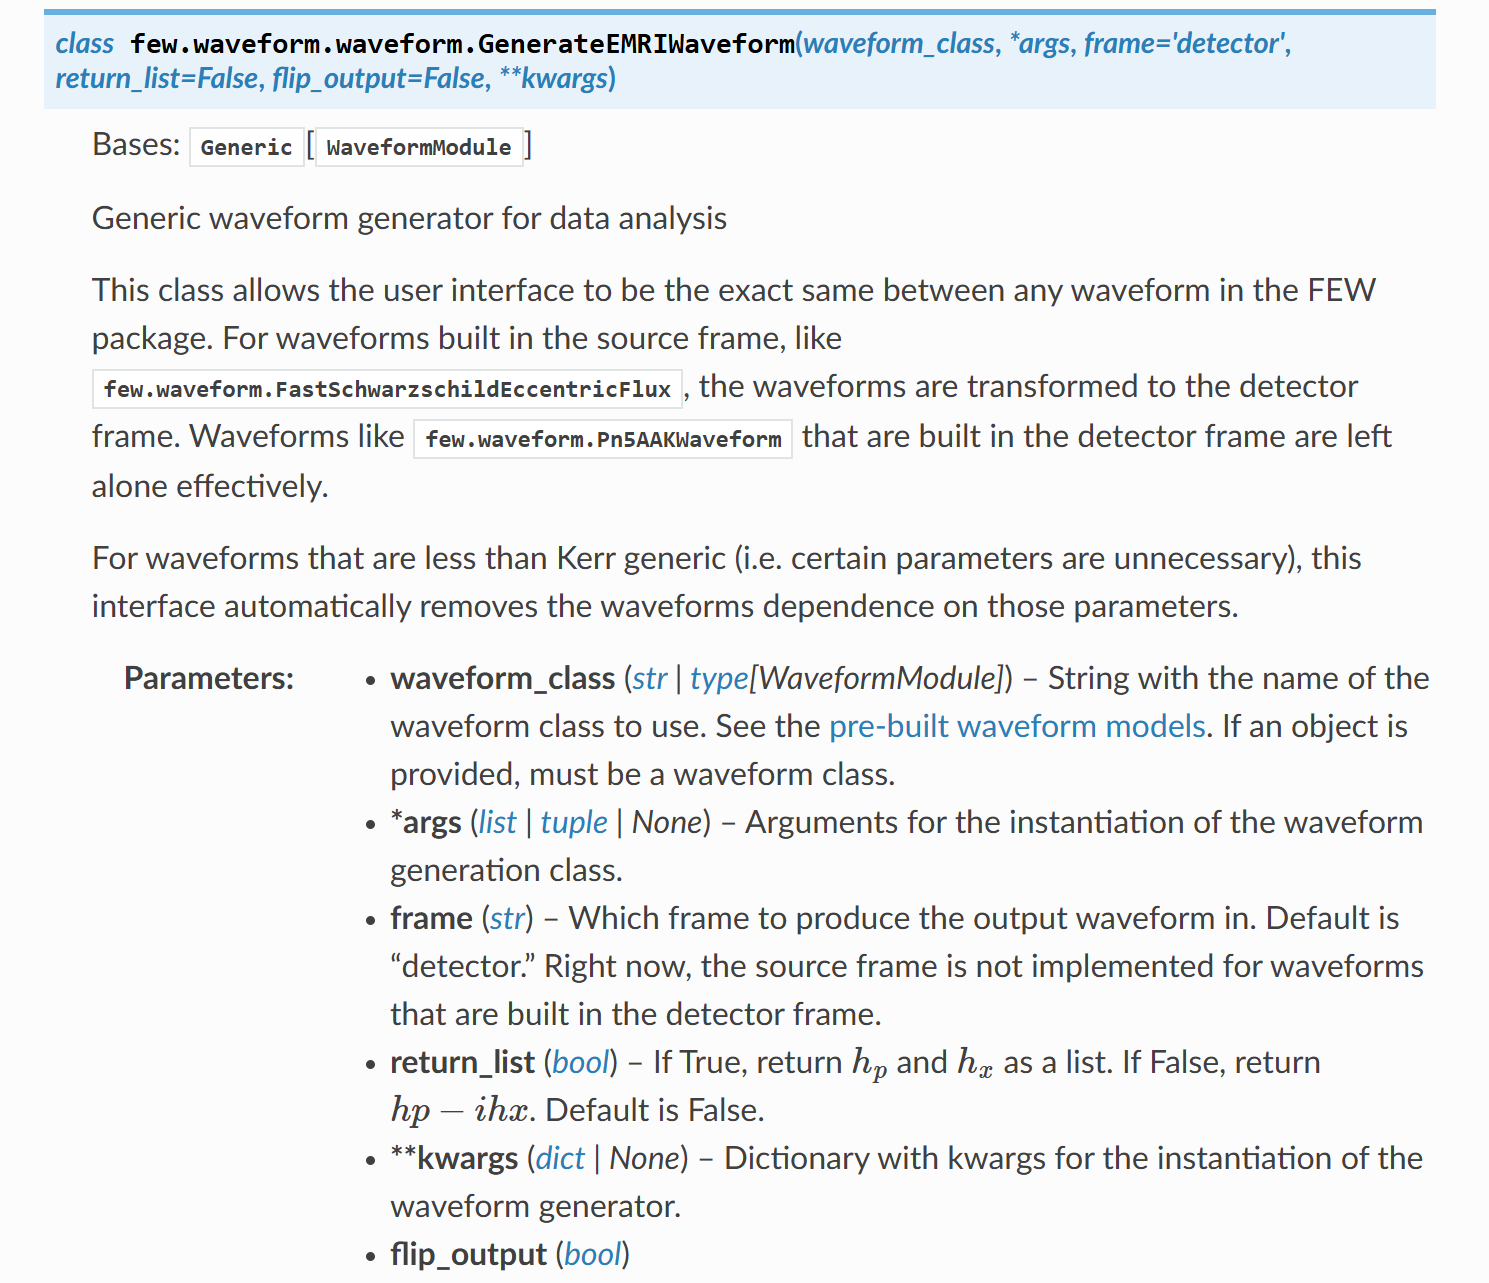
``waveform_class``是强制传入，因为没有初试的预设值。所以必须传入。

对于``__call__``先实例化（配置），再调用（运行）
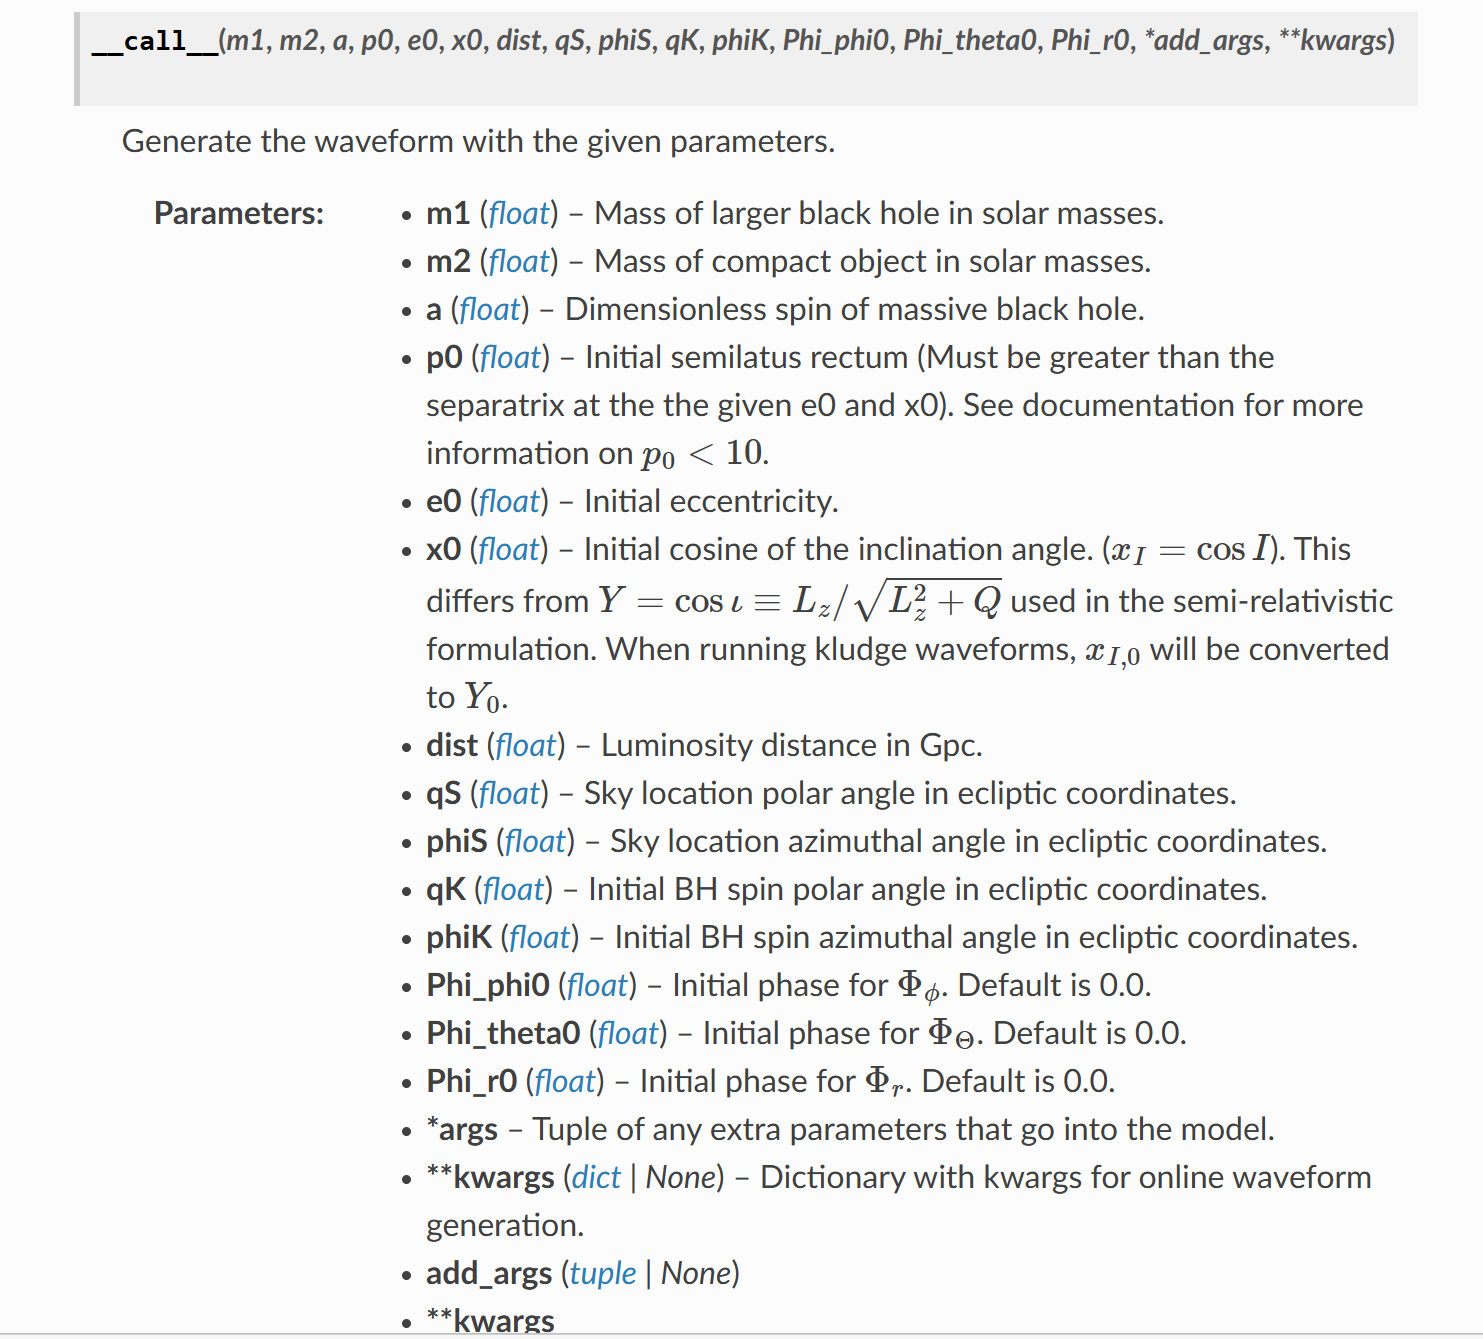

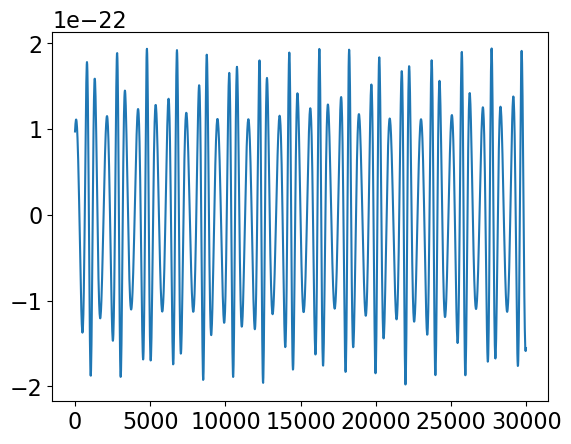

In [20]:
gen_wave = GenerateEMRIWaveform(waveform_class="FastSchwarzschildEccentricFlux")

T = 0.1  # years
dt = 15.0  # seconds
M = 1e6
a = 0.1  # will be ignored in Schwarzschild waveform
mu = 1e1
p0 = 12.0
e0 = 0.2
x0 = 1.0  # will be ignored in Schwarzschild waveform
qK = 0.2  # polar spin angle
phiK = 0.2  # azimuthal viewing angle
qS = 0.3  # polar sky angle
phiS = 0.3  # azimuthal viewing angle
dist = 1.0  # distance
Phi_phi0 = 1.0
Phi_theta0 = 2.0
Phi_r0 = 3.0

h = gen_wave(
    M,
    mu,
    a,
    p0,
    e0,
    x0,
    dist,
    qS,
    phiS,
    qK,
    phiK,
    Phi_phi0,
    Phi_theta0,
    Phi_r0,
    T=T,
    dt=dt,
)

plt.plot(np.arange(2000) * dt, h.real[:2000])

### Question

Why does the EMRI waveform look like that? This is obviously a very open-ended question. Try to decipher why the waveform has such a structure in terms of the compact object orbits.

EMRI的半径振幅看上去是大小交替的。这或许是由于具有一定偏心率的原因。

## Task 2: Add the LISA response function

When actually building the LISA response function in the time-domain, the edges of the data can be complicated. This is due to the various delays included in the instrument response and Time Delay Interferometry (TDI) transforms. In short, summations between the waveform at the current time and times in the past require that we start our computations a bit after the beginning of observation: if you cannot reach into the past enough (i.e. the delay causes the time to be less than 0.0).

Now we will wrap the EMRI waveforms in LISA response using `ResponseWrapper` from `fastlisasresponse`.

Useful documentation:
* [ResponseWrapper](https://mikekatz04.github.io/lisa-on-gpu/html/user/main.html#fastlisaresponse.response.ResponseWrapper)
* [pyResponseTDI](https://mikekatz04.github.io/lisa-on-gpu/html/user/main.html#fastlisaresponse.response.pyResponseTDI)
* [EqualArmlengthOrbits](https://mikekatz04.github.io/LISAanalysistools/build/html/user/main.html#lisatools.detector.EqualArmlengthOrbits)

In [21]:
# imports
from fastlisaresponse import ResponseWrapper
from lisatools.detector import EqualArmlengthOrbits

LISA有两条预设轨道选择
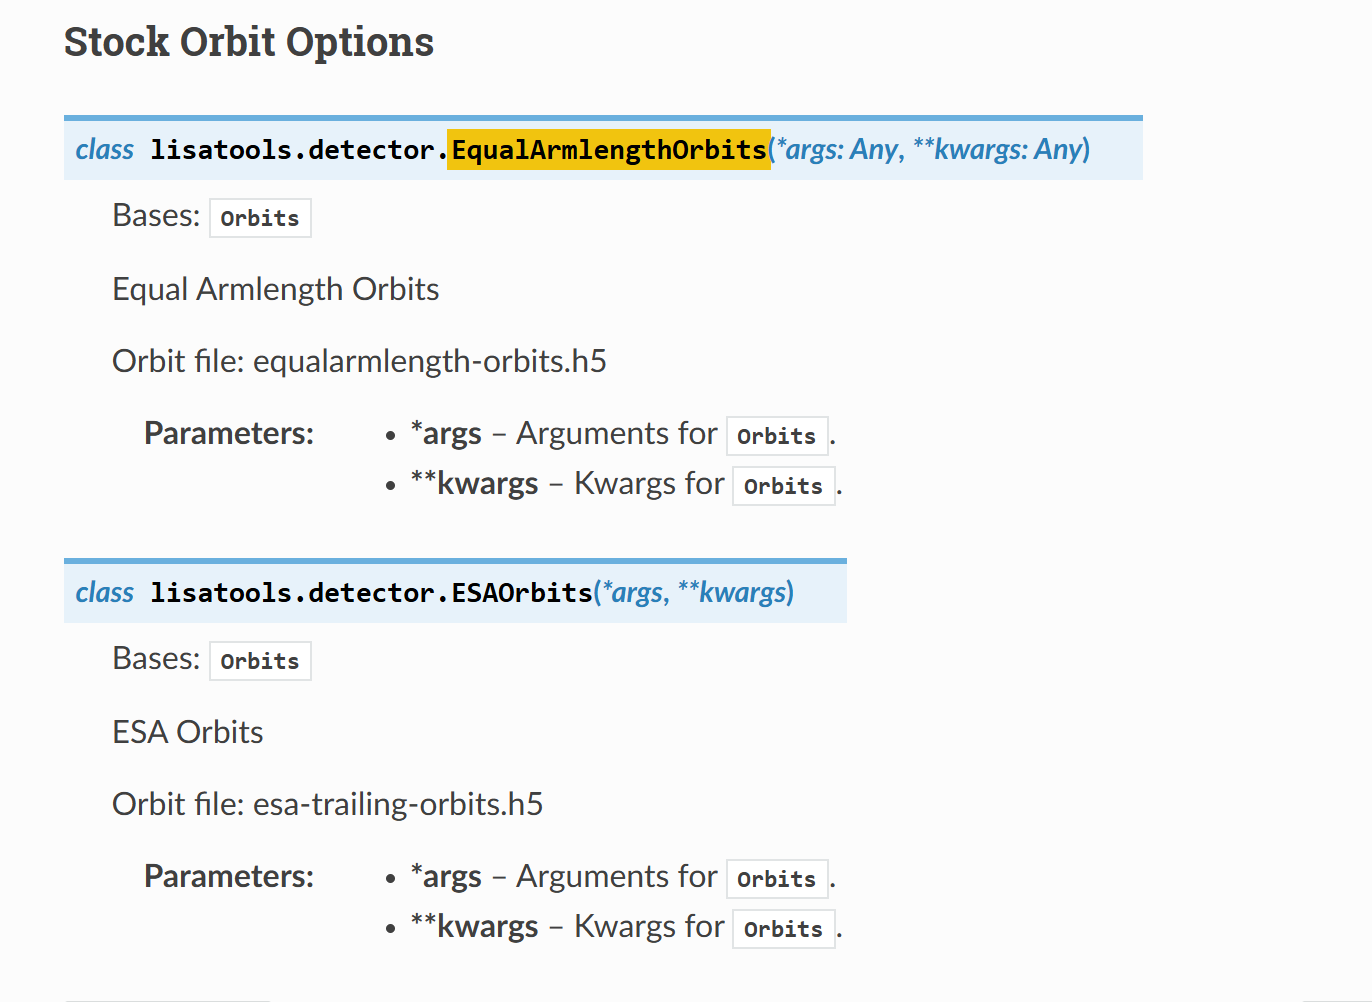
在``from xxx import xxx``也可以从参考文档中看出

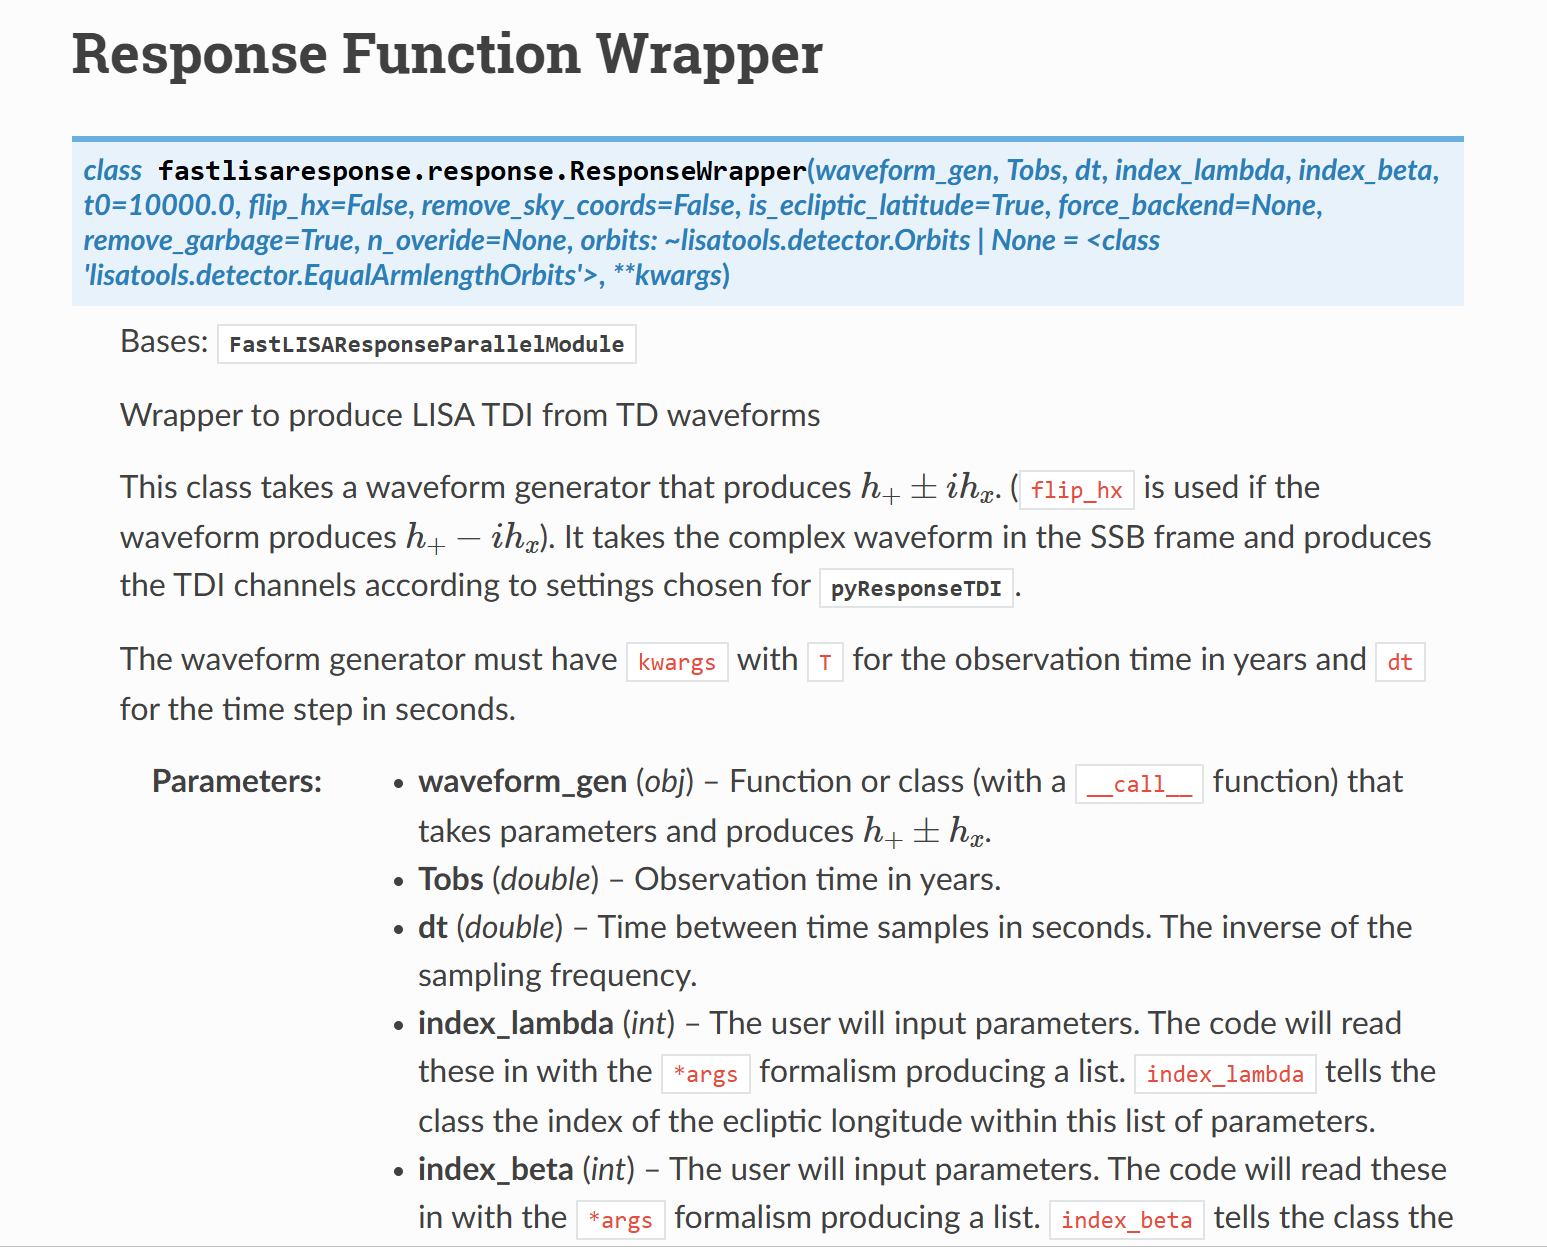
从上传到下，这个看的也比较清楚。TD 是 Time-Domain（时域）的缩写
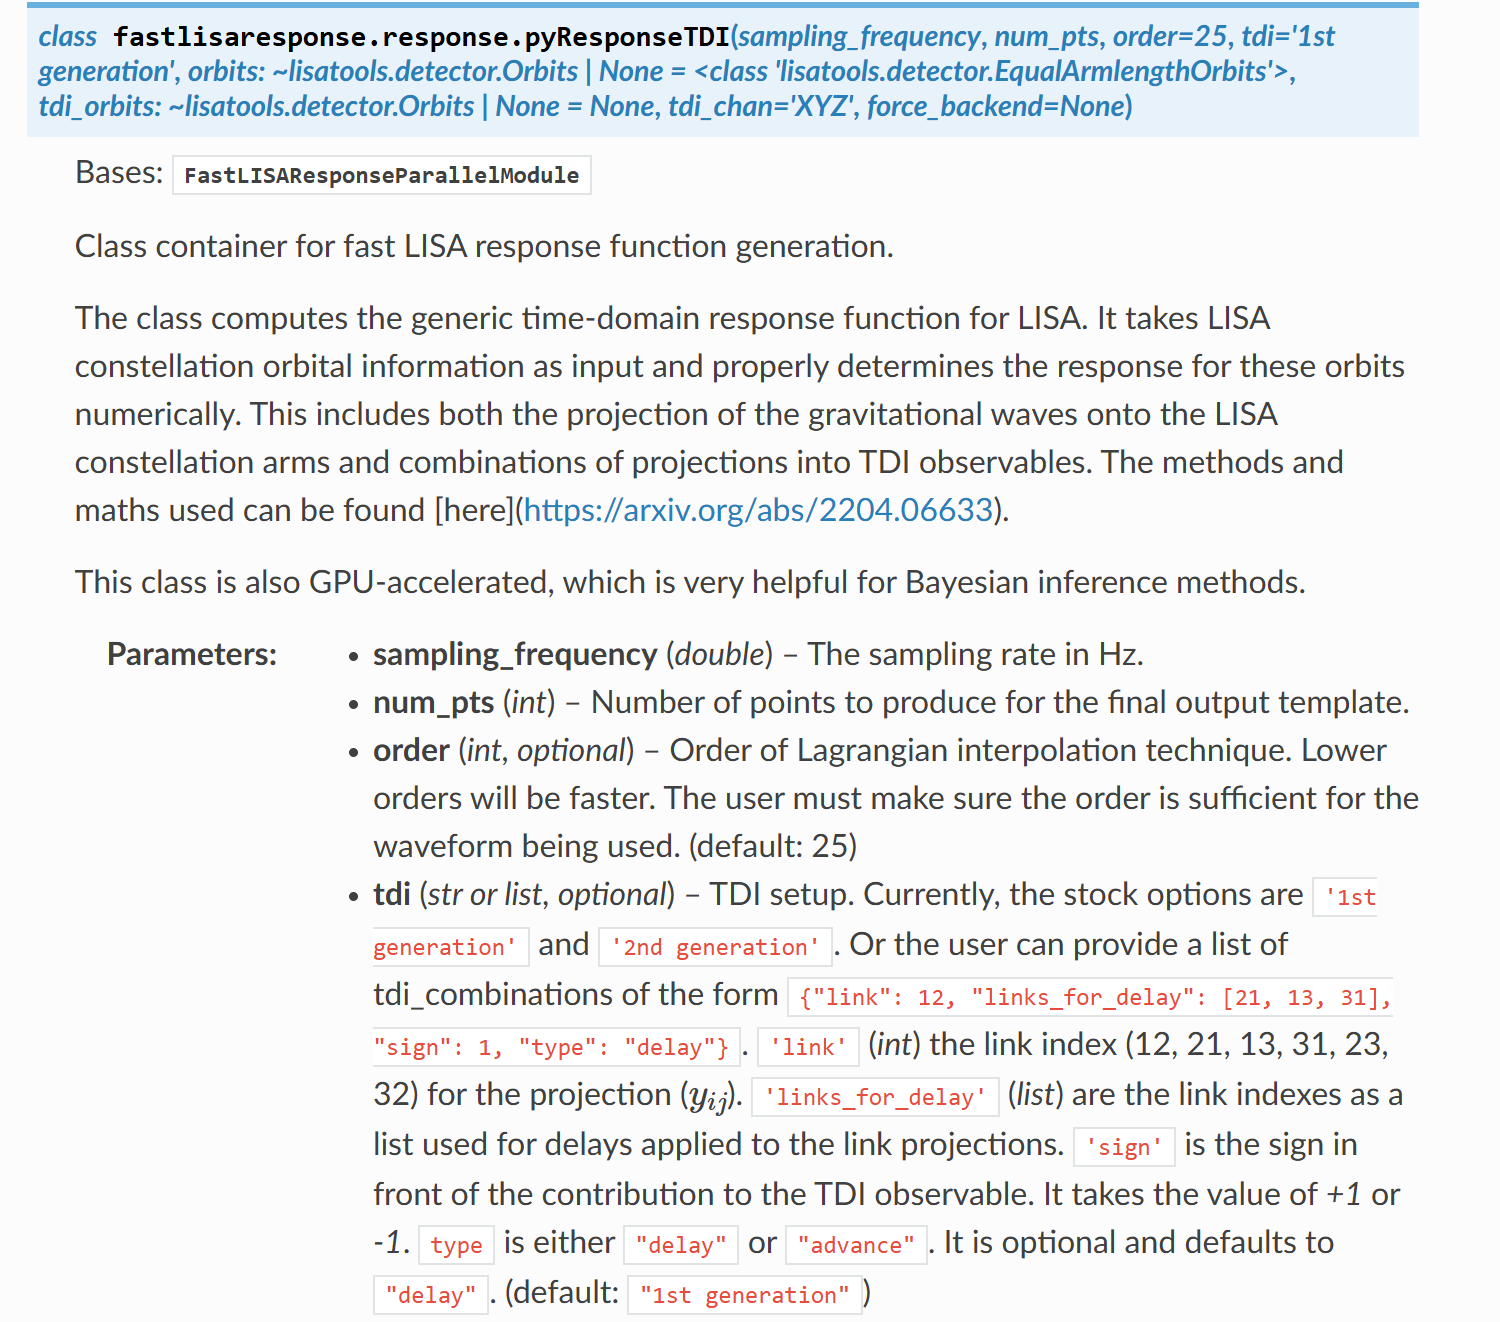

一定要在``EqualArmlengthOrbits``后面加上``()``，因为不加（）这只是一个class（类），如果加上``()``则就实例化了，它就可以用了。

In [22]:
sampling_frequency = 1 / dt
t0 = 20000.0
order = 25
orbits = EqualArmlengthOrbits()
tdi_gen = "1st generation"
index_lambda = 8
index_beta = 7
tdi_kwargs = dict(
    order=order, tdi=tdi_gen, tdi_chan="AET",
)
emri_lisa = ResponseWrapper(
    gen_wave,
    T,
    dt,
    index_lambda,
    index_beta,
    t0=t0,
    flip_hx=True,  # set to True if waveform is h+ - ihx
    remove_sky_coords=False,  # True if the waveform generator does not take sky coordinates
    is_ecliptic_latitude=False,  # False if using polar angle (theta)
    remove_garbage=True,  # removes the beginning of the signal that has bad information
    orbits=orbits,
    **tdi_kwargs,
)

In [23]:
emri_lisa??

<unknown>:670: SyntaxWarning: invalid escape sequence '\p'
<unknown>:4: SyntaxWarning: invalid escape sequence '\p'


Signature:      emri_lisa(*args, **kwargs)
Type:           ResponseWrapper
String form:    <fastlisaresponse.response.ResponseWrapper object at 0x70792f055700>
File:           ~/miniconda3/envs/lisa_env/lib/python3.12/site-packages/fastlisaresponse/response.py
Source:        
class ResponseWrapper(FastLISAResponseParallelModule):
    """Wrapper to produce LISA TDI from TD waveforms

    This class takes a waveform generator that produces :math:`h_+ \pm ih_x`.
    (:code:`flip_hx` is used if the waveform produces :math:`h_+ - ih_x`).
    It takes the complex waveform in the SSB frame and produces the TDI channels
    according to settings chosen for :class:`pyResponseTDI`.

    The waveform generator must have :code:`kwargs` with :code:`T` for the observation
    time in years and :code:`dt` for the time step in seconds.

    Args:
        waveform_gen (obj): Function or class (with a :code:`__call__` function) that takes parameters and produces
            :math:`h_+ \pm h_x`.
        

In [24]:
AET = emri_lisa(
    M,
    mu,
    a,
    p0,
    e0,
    x0,
    dist,
    qS,
    phiS,
    qK,
    phiK,
    Phi_phi0,
    Phi_theta0,
    Phi_r0,
)

In [25]:
#emri_lisa.response_model.num_total_points
# 打印出底层模型所有的属性和方法
#print(dir(emri_lisa.response_model))
emri_lisa.response_model.num_pts

210387

``remove_garbage=True``,所以程序会直接像切面包一样，把开头 t0 和结尾同样长度的数据一刀切掉、直接删了。这是因为
在计算 LISA 的 TDI 响应时，程序需要模拟光束在 250 万公里的臂长之间来回传递（需要约 8.3 秒的时间延迟）。
这就意味着，如果要计算 $t = 0$ 时刻的 TDI 信号，程序必须去查阅过去时刻（$t < 0$）的原始波形数据。但是，宇宙不会给你 $t < 0$ 的数据！
因此，在波形刚刚开始的那段时间（也就是你之前设置的 t0），程序算出来的 TDI 结果全是缺乏历史数据支撑的错误数值（无物理意义的毛刺）。

所以下面的设置``start_ind=int(t_0/dt)``,就是给出有意义的索引，从而开始绘图。

因为设置了dt，所以最终给出的XYZ信号通过TDI（时间延迟干涉）技术，转化为3个通道AET，3个列表。3个列表分别装着dt时间点的值。

关于拉格朗日线性插值：

设置的 dt 是用来采样（录像）的帧率。
而拉格朗日插值，是程序为了计算那些“卡在两帧之间”的物理延迟，而必须使用的平滑补帧技术。25 阶就是一个经过测试的、能把“补帧误差”压低到连 LISA 极其灵敏的仪器都察觉不到的完美黄金参数。


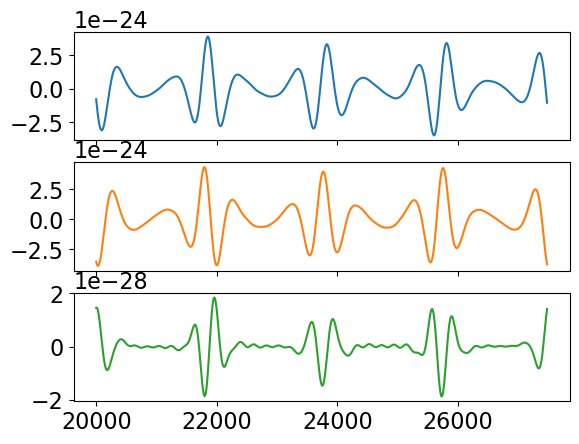

In [26]:
start_ind = int(t0 / dt)
num = 500
fig, ax = plt.subplots(3, 1, sharex=True)
for i in range(3):
    ax[i].plot((start_ind +np.arange(num)) * dt, AET[i][:num], color=f"C{i}")

### Question

With a long-enough observation time, you will see a new envelope structure to the waveforms when the response is added. Why is that? 

LISA的空间位置在不断的旋转，则会由信号强的区域，和信号弱的区域。

If you want to use `ResponseWrapper` with another type of waveform, the above cells are how you do that. If you want to use `GenerateEMRIWaveform` and `ResponseWrapper` together, you can use the stock model from LISA Analysis Tools: [EMRITDIWaveform](https://mikekatz04.github.io/LISAanalysistools/build/html/user/sources.html#lisatools.sources.emri.EMRITDIWaveform). With this class, you do not have to set any choices. In this case, it will set it up with all defaults. Generate the same waveform above but now with the new class. 

Documentation:
* [EMRITDIWaveform](https://mikekatz04.github.io/LISAanalysistools/build/html/user/sources.html#lisatools.sources.emri.EMRITDIWaveform)

In [27]:
# imports
from lisatools.sources.emri import EMRITDIWaveform

    """Generate EMRI waveforms with the TDI LISA Response.

    Args:
        T: Observation time in years.
        dt: Time cadence in seconds.
        emri_waveform_args: Arguments for :class:`GenerateEMRIWaveforms`.
        emri_waveform_kwargs: Keyword arguments for :class:`GenerateEMRIWaveforms`.
        response_kwargs: Keyword arguments for :class:`ResponseWrapper`.

    """
库文档中，这个参考文档中并没有

In [28]:
emri_lisa = EMRITDIWaveform(response_kwargs=dict(tdi_chan="AE"))
AET1=emri_lisa(
    M,
    mu,
    a,
    p0,
    e0,
    x0,
    dist,
    qS,
    phiS,
    qK,
    phiK,
    Phi_phi0,
    Phi_theta0,
    Phi_r0,
    T=T,
    dt=dt,
)

for i in range(2):
    ax[i].plot(AET1[i]) 

## Task 3: Calculate SNR, inner product, and Likelihood

Now we will combine our knowledge from tutorials 1 and 2 to calculate the SNR, inner product, and Likelihood for an EMRI.

Let's start by generating our data for *just* the A and E channels (do not worry about T for now). Be careful, make sure when using `EMRITDIWaveform`, you initialize with the keyword argument `response_kwargs=dict(tdi_chan="AE")` to remove the T channel. Fill a [DataResidualArray](https://mikekatz04.github.io/LISAanalysistools/build/html/user/datacontainer.html#lisatools.datacontainer.DataResidualArray) with the data. Plot it if you would like. 

In [29]:
from lisatools.datacontainer import DataResidualArray

In [30]:
emri_lisa = EMRITDIWaveform(response_kwargs=dict(tdi_chan="AE"))
AE = emri_lisa(
    M,
    mu,
    a,
    p0,
    e0,
    x0,
    dist,
    qS,
    phiS,
    qK,
    phiK,
    Phi_phi0,
    Phi_theta0,
    Phi_r0,
)

data = DataResidualArray(AE, dt=dt)

(<Figure size 640x480 with 2 Axes>, array([<Axes: >, <Axes: >], dtype=object))

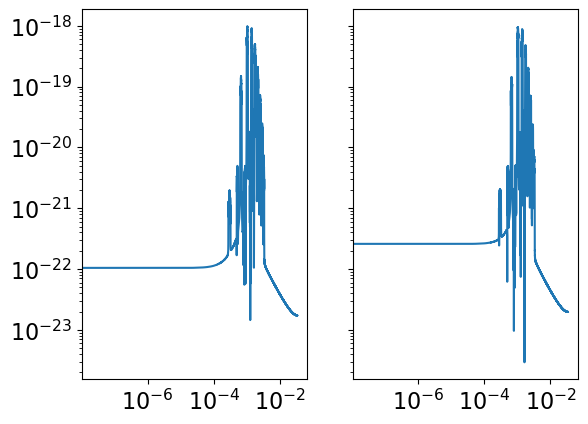

In [31]:
data.loglog()

Now let's build the [SensitivityMatrix](https://mikekatz04.github.io/LISAanalysistools/build/html/user/sensitivity.html#lisatools.sensitivity.SensitivityMatrix). Remeber, we now have the response function included. Therefore, we do not want to use [LISASens](https://mikekatz04.github.io/LISAanalysistools/build/html/user/sensitivity.html#lisatools.sensitivity.LISASens). Rather, we will use the TDI sensitivity functions: [A1TDISens](https://mikekatz04.github.io/LISAanalysistools/build/html/user/sensitivity.html#lisatools.sensitivity.A1TDISens), [E1TDISens](https://mikekatz04.github.io/LISAanalysistools/build/html/user/sensitivity.html#lisatools.sensitivity.E1TDISens).

In [32]:
from lisatools.sensitivity import SensitivityMatrix, A1TDISens, E1TDISens

在SensitityMatrix中调用，``A1DISens``和``E1TDISens``是使用这种方法，所以调用的是一个类（class），其有两个作用Transform from the base sensitivity functions to the TDI PSDs.和Transform from the base stochastic functions to the TDI PSDs.返还A，E道的灵敏矩阵和随机函数的灵敏矩阵。

源码里的 @staticmethod（静态方法） 装饰器上。
静态方法意味着：这个计算配方是直接绑在这个类身上的公共工具，它不需要被实例化。当底层代码需要算噪声时，它会直接拿着频率数组 $f$，去调用 A1TDISens.transform(f, ...)，立刻就能拿到结果。

返还的是数组，最后组装成矩阵

In [33]:
sens_mat = SensitivityMatrix(data.f_arr, [A1TDISens, E1TDISens])

/home/yudh/miniconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/detector.py:655: RuntimeWarning: divide by zero encountered in divide
  Sa_a = Sa_a_in * (1.0 + (0.4e-3 / frq) ** 2) * (1.0 + (frq / 8e-3) ** 4)
/home/yudh/miniconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/detector.py:657: RuntimeWarning: divide by zero encountered in power
  Sa_d = Sa_a * (2.0 * np.pi * frq) ** (-4.0)
/home/yudh/miniconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/detector.py:659: RuntimeWarning: invalid value encountered in multiply
  Sa_nu = Sa_d * (2.0 * np.pi * frq / C_SI) ** 2
/home/yudh/miniconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/detector.py:664: RuntimeWarning: divide by zero encountered in divide
  Soms_d = Soms_d_in * (1.0 + (2.0e-3 / f) ** 4)
/home/yudh/miniconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/detector.py:666: RuntimeWarning: invalid value encountered in multiply
  Soms_nu = Soms_d * (2.0 * np.pi * frq / C_SI) ** 2


Now pack them both into the [AnalysisContainer](https://mikekatz04.github.io/LISAanalysistools/build/html/user/datacontainer.html#lisatools.analysiscontainer.AnalysisContainer) and calculate the SNR of the injection data.

In [34]:
from lisatools.analysiscontainer import AnalysisContainer

In [35]:
analysis=AnalysisContainer(data_res_arr=data,sens_mat=sens_mat,signal_gen=emri_lisa)
analysis.snr()

43.6564350185569

In [36]:
analysis.likelihood(source_only=True)

-952.9421592647407

(<Figure size 640x480 with 2 Axes>, array([<Axes: >, <Axes: >], dtype=object))

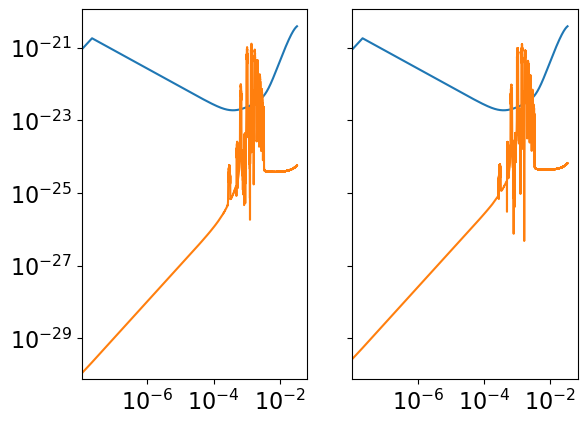

In [37]:
analysis.loglog()

Now, let's calculate the Likelihood using `AnalysisContainer.calculate_signal_likelihood`. This allows us to compare another EMRI signal to our injection. Start by injecting a source with the correct injection parameters. What is the Likelihood here? Now change the source parameters slightly one at a time and observe how the Likelihood changes. This can give you a sense of the complicated multidimensional Likelihood surface which we wish to learn. Since we are fixing the sensitivity for now, add the `source_only=False` keyword argument. 

In [38]:
analysis.calculate_signal_likelihood(
    M * 1.00000005,
    mu,
    a,
    p0,
    e0,
    x0,
    dist,
    qS,
    phiS,
    qK,
    phiK,
    Phi_phi0,
    Phi_theta0,
    Phi_r0,
    source_only=True
)


np.float64(-0.14943392239501918)

In [39]:
analysis.calculate_signal_likelihood(
    M * 1.00000005,
    mu,
    a,
    p0,
    e0,
    x0,
    dist,
    qS,
    phiS,
    qK,
    phiK,
    Phi_phi0,
    Phi_theta0,
    Phi_r0,
    source_only=False
)


np.float64(292708974.77313095)

In [40]:
analysis.calculate_signal_likelihood(
    M,
    mu,
    a,
    p0,
    e0,
    x0,
    dist,
    qS,
    phiS,
    qK,
    phiK,
    Phi_phi0,
    Phi_theta0,
    Phi_r0,
    source_only=True
)

np.float64(-0.0)

## Task 4: Determine 1$\sigma$ width in 1-dimension using the Likelihood

In one dimension, the 1$\sigma$ Likelihood width can be determined by solving $\log{\mathcal{L(\vec{\theta})}} = -1$. Using a loop, plot the Likelihood versus one parameter you decide to change. Make sure the Likelihoods are all of order $\sim1$, so close to the true value. To make sure this works as an examples, it is advisable to use just one mode by setting `waveform_kwargs=dict(mode=[(2, 2, 0)]` (you can use any mode). 

In [41]:
x = np.linspace(-0.05, 0.05, 20)
y = np.zeros_like(x)
for i in range(len(x)):
    diff = 1.0 + x[i]
    y[i] = analysis.calculate_signal_likelihood(
        M,
        mu,
        a,
        p0,
        e0,
        x0,
        dist * diff,
        qS,
        phiS,
        qK,
        phiK,
        Phi_phi0,
        Phi_theta0,
        Phi_r0,
        source_only=True,
    )


In [42]:
analysis.calculate_signal_likelihood(
        M,
        mu,
        a,
        p0,
        e0,
        x0,
        dist,
        qS,
        phiS,
        qK,
        phiK,
        Phi_phi0,
        Phi_theta0,
        Phi_r0,
        source_only=True,
        waveform_kwargs=dict(mode_selection=[(2, 2, 0)])
    )

np.float64(-595.3482465177312)

Use whatever method you prefer to determine the $1\sigma$ width. You can eyeball it or use plotting. We are just estimating the value for now. 

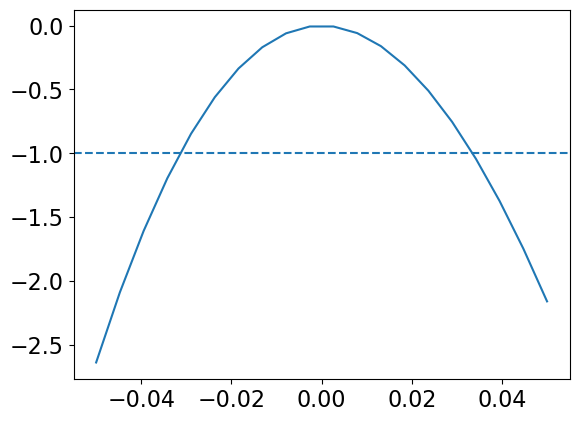

In [43]:
plt.plot(x, y)
plt.axhline(-1.0, ls='--')

## Task 5: analyze a GR modification or environmental effect

Now we will look at a very useful aspect of `few`: testing beyond-GR or environmental effects by adding terms to the Trajectory. Here, we will use a modified trajectory that we have already put together for you. The modificiation is `pdot = pdot * (1 + mod)` and `edot = edot * (1 + mod)`.

It is imported below (`ModifiedPnTrajectory`). It is a basic PN trajectory in the Schwarzschild eccentric limit. This is effectively lifted from the `few` tutorial (adding the GR modification). For the amplitude module, use `Interp2DAmplitude` and for the summation use `InterpolatedModeSum`. **Hint**: You are created a class object that inherits `SchwarzschildEccentricWaveformBase` and initializes it with the proper modules. See the tutorial. It does this exactly.

Documentation:
* [SchwarzschildEccentricWaveformBase](https://bhptoolkit.org/FastEMRIWaveforms/html/user/main.html#few.waveform.SchwarzschildEccentricWaveformBase)
* [Make waveform tutorial](https://bhptoolkit.org/FastEMRIWaveforms/html/tutorial/FastEMRIWaveforms_tutorial.html#Make-a-waveform-model)

In [44]:
from pnbeyondGR_example import ModifiedPnTrajectory
from few.waveform.base import SphericalHarmonicWaveformBase
# from few.amplitude.ampinterp2d import AmpInterp2D
from few.amplitude.ampinterp2d import AmpInterpSchwarzEcc
from few.summation.interpolatedmodesum import InterpolatedModeSum

🟢 第一步：诊断报错

当你运行旧代码时，通常会遇到这两种致命报错：

1. **`ModuleNotFoundError: No module named 'A.B.C'`**
   * **人话翻译**：Python 说：“我顺着 `A` 文件夹找到了 `B` 文件夹，但是里面根本没有叫 `C.py` 的文件，或者连 `B` 这个文件夹都被开发者整个端掉了！”
   * **根本原因**：开发者重构了文件目录结构。

2. **`ImportError: cannot import name 'X' from 'A.B'`**
   * **人话翻译**：Python 说：“我确实找到了 `A.B` 这个文件，但我翻遍了里面的每一行代码，都没有找到叫 `X` 的类或者函数！”
   * **根本原因**：文件还在，但里面的类被**改名了**，或者被**删除了**。

---

🟡 第二步：下达“搜查令”（终端 `grep` 大法）

既然旧路走不通，我们就直接去源码的“老巢”里全局搜索。在 Linux/WSL 终端输入：

```bash
grep -rn "class .*WaveformBase" ~/miniconda3/envs/lisa_env/lib/python3.12/site-packages/few/
```

**🔎 这串代码到底是什么意思？（逐字解析）：**
* **`grep`**：Linux 下最强大的文本搜索工具（Global Regular Expression Print）。
* **`-r`**：递归（Recursive）。意思是“不要只搜表层，把文件夹里的文件夹，一层层全部给我刨开搜”。
* **`-n`**：行号（Number）。搜索结果必须告诉我在这句话在文件的第几行（方便定位）。
* **`"class .*WaveformBase"`**：你要搜的核心目标。
  * `class `：说明我要找的是一个类（不是普通的变量或注释）。
  * `.*`：**正则通配符（精髓）**。意思是“不管前面加了什么前缀（不管是 `SchwarzschildEccentric` 还是其他什么鬼），只要名字最后是以 `WaveformBase` 结尾的，全给我抓出来”。
* **`~/miniconda3/.../few/`**：搜查范围。也就是你当前环境里 `few` 这个包的绝对安装路径。

---

🟠 第三步：解读情报（把 Linux 语言翻译成 Python 语句）

这是最关键的一步！拿你刚才终端吐出来的一条真实结果为例：

> `/home/yudh/miniconda3/envs/lisa_env/lib/python3.12/site-packages/few/waveform/base.py:31:class SphericalHarmonicWaveformBase(`

我们把它像切香肠一样切成三段来看：

1. **路径段**：`.../site-packages/few/waveform/base.py`
   * **提取逻辑**：把 `site-packages/` 后面的路径提取出来，把斜杠 `/` 换成英文句点 `.`，把 `.py` 后缀砍掉。
   * **翻译结果**：`few.waveform.base` （这就是你 Python 里的 `from ...` 部分）。
2. **行号段**：`:31:`
   * 确认它在第 31 行，是真实存在的代码。
3. **实体段**：`class SphericalHarmonicWaveformBase(`
   * **提取逻辑**：剥离掉 `class` 和括号。
   * **翻译结果**：`SphericalHarmonicWaveformBase` （这就是你 Python 里的 `import ...` 部分）。

**✨ 终极组装**：通过这一条终端信息，我们就能写出 100% 正确的新版导入语句：
`from few.waveform.base import SphericalHarmonicWaveformBase`

---

🔴 第四步：拍板决定（确定最终结果）

有时候 `grep` 会吐出好几条结果（比如你刚才搜出来了 `Pn5AAKWaveform` 和 `SphericalHarmonicWaveformBase` 等等）。怎么选？

* **看词根和物理意义**：以前的旧教程叫 `SchwarzschildEccentricWaveformBase`（史瓦西偏心波形基类）。现在没有这个词了，但我们知道史瓦西波形本质上是球面谐波（Spherical Harmonic）展开。所以对比之下，`SphericalHarmonicWaveformBase` 就是那个真正继承了它衣钵的“新基类”。

Now we will look at a very useful aspect of `few`: testing beyond-GR or environmental effects by adding terms to the Trajectory. Here, we will use a modified trajectory that we have already put together for you. The modificiation is `pdot = pdot * (1 + mod)` and `edot = edot * (1 + mod)`.

It is imported below (`ModifiedPnTrajectory`). It is a basic PN trajectory in the Schwarzschild eccentric limit. This is effectively lifted from the `few` tutorial (adding the GR modification). For the amplitude module, use `Interp2DAmplitude` and for the summation use `InterpolatedModeSum`. **Hint**: You are created a class object that inherits `SchwarzschildEccentricWaveformBase` and initializes it with the proper modules. See the tutorial. It does this exactly.

Documentation:
* [SchwarzschildEccentricWaveformBase](https://bhptoolkit.org/FastEMRIWaveforms/html/user/main.html#few.waveform.SchwarzschildEccentricWaveformBase)
* [Make waveform tutorial](https://bhptoolkit.org/FastEMRIWaveforms/html/tutorial/FastEMRIWaveforms_tutorial.html#Make-a-waveform-model)

from pnbeyondGR_example import ModifiedPnTrajectory

from few.waveform.base import SphericalHarmonicWaveformBase

from few.amplitude.ampinterp2d import AmpInterp2D

from few.summation.interpolatedmodesum import InterpolatedModeSum

Create the waveform generator class to start. Look at the FEW tutorial. It has an exact [example](https://bhptoolkit.org/FastEMRIWaveforms/html/tutorial/FastEMRIWaveforms_tutorial.html#Make-a-waveform-model) of how to do this.

In [45]:
# 确保你已经 import 了这个模式选择器
from few.utils.modeselector import ModeSelector

class FastSchwarzschildEccentricPn(SphericalHarmonicWaveformBase):
    def __init__(
        self,
        inspiral_kwargs={},
        amplitude_kwargs={},
        sum_kwargs={},
        Ylm_kwargs={},
        mode_selector_kwargs={}, # 加上这个
        force_backend=None,      # 2.0 里把 use_gpu 改成了 force_backend
        *args,
        **kwargs
    ):
        super().__init__(
            ModifiedPnTrajectory,  # 1. 轨道
            AmpInterpSchwarzEcc,           # 2. 振幅
            InterpolatedModeSum,   # 3. 求和
            ModeSelector,          # 4. 模式选择器 (2.0 强制新增的必须零件！)
            
            # 下面这些是按名字传递的配置字典
            inspiral_kwargs=inspiral_kwargs,
            amplitude_kwargs=amplitude_kwargs,
            sum_kwargs=sum_kwargs,
            Ylm_kwargs=Ylm_kwargs,
            mode_selector_kwargs=mode_selector_kwargs,
            force_backend=force_backend,
            *args,
            **kwargs
        )
    @classmethod
    def supported_backends(cls):
        # 告诉底层：我推荐用 GPU，但也兼容 CPU
        return cls.GPU_RECOMMENDED()

    @property
    def allow_batching(self):
        # 告诉底层：我不支持一次性打包算几百个黑洞
        return False

In [ ]:
# # 1. 导入 2.0 版本拆分后的数据仓库基类
# from few.utils.baseclasses import SchwarzschildEccentric

# # 2. 导入其他的必需模块
# from few.waveform.base import SphericalHarmonicWaveformBase
# from few.utils.modeselector import ModeSelector
# from few.amplitude.ampinterp2d import AmpInterpSchwarzEcc
# from few.summation.interpolatedmodesum import InterpolatedModeSum

# # 多重继承：左手拿流水线，右手拿物理数据仓库
# class FastSchwarzschildEccentricPn(SphericalHarmonicWaveformBase, SchwarzschildEccentric):
#     def __init__(
#         self,
#         inspiral_kwargs={},
#         amplitude_kwargs={},
#         sum_kwargs={},
#         Ylm_kwargs={},
#         mode_selector_kwargs={}, 
#         force_backend=None,      
#         *args,
#         **kwargs
#     ):
        
#         # 第一步：先初始化物理数据仓库（生成 l_arr_no_mask 等核心数组）
#         # 旧式的显式调用在这里是必须的，因为我们要精确控制初始化哪一个父类
#         SchwarzschildEccentric.__init__(
#             self,
#             **{k: v for k, v in kwargs.items() if k in ["lmax", "ndim", "nmax"]},
#             force_backend=force_backend,
#         )

#         # 第二步：初始化流水线调度员，把零件全塞进去
#         SphericalHarmonicWaveformBase.__init__(
#             self,
#             inspiral_module=ModifiedPnTrajectory,  # 你的魔改轨道
#             amplitude_module=AmpInterpSchwarzEcc,  # 自带数据的振幅模块
#             sum_module=InterpolatedModeSum,        # 求和模块
#             mode_selector_module=ModeSelector,     # 2.0 强制要求的模式选择器
#             inspiral_kwargs=inspiral_kwargs,
#             amplitude_kwargs=amplitude_kwargs,
#             sum_kwargs=sum_kwargs,
#             Ylm_kwargs=Ylm_kwargs,
#             mode_selector_kwargs=mode_selector_kwargs,
#             force_backend=force_backend,
#         )

#     # 2.0 强制要求的硬件兼容性声明
#     @classmethod
#     def supported_backends(cls):
#         return cls.GPU_RECOMMENDED()

#     @property
#     def allow_batching(self):
#         return False

In [ ]:
from few.utils.baseclasses import SchwarzschildEccentric
from few.waveform.base import SphericalHarmonicWaveformBase
from few.utils.modeselector import ModeSelector
from few.amplitude.ampinterp2d import AmpInterpSchwarzEcc
# 🚨 破局点：导入直接求和模块，抛弃教程里的 InterpolatedModeSum
from few.summation.directmodesum import DirectModeSum 
from pnbeyondGR_example import ModifiedPnTrajectory

class FastSchwarzschildEccentricPn(SphericalHarmonicWaveformBase, SchwarzschildEccentric):
    def __init__(self, inspiral_kwargs={}, amplitude_kwargs={}, sum_kwargs={}, Ylm_kwargs={}, mode_selector_kwargs={}, force_backend=None, *args, **kwargs):
        nmax = kwargs.get("nmax", 30)
        SchwarzschildEccentric.__init__(self, **{k: v for k, v in kwargs.items() if k in ["lmax", "ndim"]}, nmax=nmax, force_backend=force_backend)
        
        SphericalHarmonicWaveformBase.__init__(self, inspiral_module=ModifiedPnTrajectory, amplitude_module=AmpInterpSchwarzEcc, sum_module=DirectModeSum, mode_selector_module=ModeSelector, inspiral_kwargs=inspiral_kwargs, amplitude_kwargs=amplitude_kwargs, sum_kwargs=sum_kwargs, Ylm_kwargs=Ylm_kwargs, mode_selector_kwargs=mode_selector_kwargs, force_backend=force_backend)
        
        self.inspiral_generator.dense_stepping = True 
        self.inspiral_generator.integrate_backwards = False

    @classmethod
    def supported_backends(cls):
        return cls.GPU_RECOMMENDED()

    @property
    def allow_batching(self):
        return False

    def __call__(self, m1, m2, p0, e0, theta, phi, *args, **kwargs):
        return self._generate_waveform(m1, m2, 0.0, p0, e0, 1.0, theta, phi, *args, **kwargs)

Now use `EMRITDIWaveform` to create a full TDI version of this waveform. **Hint**: use the `emri_waveform_args` keyword argument for the EMRITDIWaveform. Also, use just the A and E channels. Supply the `response_kwargs` keyword argument to specify this. Build the injection waveforms and place them in a `DataResidualArray`. Then, fill an `AnalysisContainer` with the sensitivity matrix, data, and signal generator as we have done before. **Hint**: the modification parameter will be added as the last parameter.

In [68]:
new_emri_lisa = EMRITDIWaveform(
    emri_waveform_args=(FastSchwarzschildEccentricPn,),
    emri_waveform_kwargs=dict(inspiral_kwargs=dict(func="SchwarzEccFlux")),
    response_kwargs=dict(tdi_chan="AE")
)

Now do some basic calculations (Likelihood, overlap, etc.) to understand how the added effect changes our waveform. **Hint**: you can get the overlap by calculating the inner product with the keyword argument `normalize=True`. 

In [69]:
modification = 0.0

injection = new_emri_lisa(
    M,
    mu,
    a,
    p0,
    e0,
    x0,
    dist,
    qS,
    phiS,
    qK,
    phiK,
    Phi_phi0,
    Phi_theta0,
    Phi_r0,
    modification
)

data = DataResidualArray(injection, dt=dt)
analysis = AnalysisContainer(data, sens_mat, signal_gen=new_emri_lisa)


AssertionError: 

这玩意很难修。。。。